In [1]:
import msprime
import numpy as np  # Importing NumPy for numerical operations
import os  # Importing os for operating system functionalities
import argparse  # Importing argparse for command-line argument parsing
import pandas as pd  # Importing pandas for DataFrame manipulation
import zipfile  # Importing zipfile for creating zip archives
import gzip
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import tskit as ts    



Population Times (in generations):
0     0.000000e+00
1     1.306869e+02
2     1.690212e+02
3     2.186001e+02
4     2.827219e+02
5     3.656524e+02
6     4.729089e+02
7     6.116269e+02
8     7.910348e+02
9     1.023068e+03
10    1.323164e+03
11    1.711287e+03
12    2.213257e+03
13    2.862469e+03
14    3.702115e+03
15    4.788053e+03
16    6.192529e+03
17    8.008977e+03
18    1.035824e+04
19    1.339662e+04
20    1.732624e+04
21    2.240853e+04
22    2.898160e+04
23    3.748274e+04
24    4.847753e+04
25    6.269739e+04
26    8.108837e+04
27    1.048739e+05
28    1.356365e+05
29    1.754227e+05
30    2.268792e+05
31    2.934295e+05
32    3.795009e+05
33    4.908196e+05
34    6.347913e+05
35    8.209941e+05
36    1.061816e+06
37    1.373277e+06
38    1.776099e+06
39    2.297081e+06
Name: years_ago, dtype: float64

Population Sizes (Ne):
[7.69956164e+03 7.69956164e+03 2.71245786e+04 2.71245786e+04
 5.06080962e+04 5.06080962e+04 5.02679298e+04 5.02679298e+04
 4.97684368e+04 4.97684368e

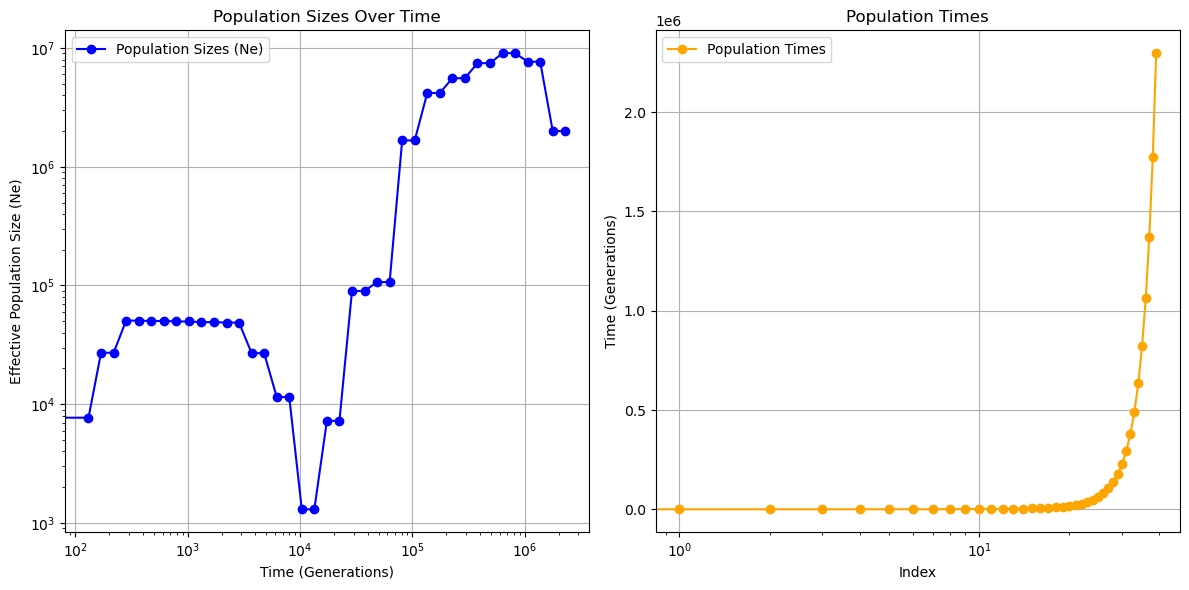

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Demography data
demography_data = {
    'years_ago': [
        0, 20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
        75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
        273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
        990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
        3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
        12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
        46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
        169890.48403, 219724.30843, 284175.84417, 367532.89150
    ],
    'Ne_log10': [
        3.886466, 3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
        4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
        4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
        4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
        3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
        6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
        6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
        6.885372, 6.885372, 6.300497, 6.300497
    ]
}

# Convert to DataFrame
demography_df = pd.DataFrame(demography_data)

# User-defined parameters
num_time_points = 40  # Number of time points for demographic changes

# Function to generate population times
def get_population_time(demography_fromdata):
    """Generate population times."""
    divided_years = demography_fromdata['years_ago'] / 0.16  # Divide years_ago by generation time
    divided_years = divided_years.sort_values()
    return divided_years  # Return sorted time points in generations

# Function to sample population sizes
def sample_population_size(num_time_points, demography_fromdata):
    """Sample population sizes based on demographic data."""
    pop_sizes = np.zeros(num_time_points)
    
    # Ensure demography_df has enough rows
    total_rows = len(demography_fromdata)
    if total_rows == 0:
        raise ValueError("The demography DataFrame is empty.")
    
    # Adjust the loop to prevent out-of-bounds indexing
    for i in range(num_time_points):
        if i >= total_rows:
            raise IndexError(f"Index {i} is out of bounds for demography DataFrame with {total_rows} rows.")
        
        log10_Ne = demography_fromdata['Ne_log10'].iloc[i]
        Ne = 10 ** log10_Ne  # Transform from log10 scale
        pop_sizes[i] = Ne  # Store population sizes
    
    return pop_sizes

# Generate the outputs
population_times = get_population_time(demography_df)  # Get population times
population_sizes = sample_population_size(num_time_points, demography_df)  # Get population sizes

# Print outputs
print("Population Times (in generations):")
print(population_times)

print("\nPopulation Sizes (Ne):")
print(population_sizes)

# Plot the outputs
plt.figure(figsize=(12, 6))

# Plot Population Sizes
plt.subplot(1, 2, 1)
plt.plot(population_times, population_sizes, marker='o', linestyle='-', color='blue', label="Population Sizes (Ne)")
plt.xscale('log')  # Log scale for years
plt.yscale('log')  # Log scale for population sizes
plt.xlabel("Time (Generations)")
plt.ylabel("Effective Population Size (Ne)")
plt.title("Population Sizes Over Time")
plt.legend()
plt.grid()

# Plot Population Times (sorted years_ago divided by 0.16)
plt.subplot(1, 2, 2)
plt.plot(population_times, marker='o', color='orange', label="Population Times")
plt.xscale('log')  # Log scale for generations
plt.xlabel("Index")
plt.ylabel("Time (Generations)")
plt.title("Population Times")
plt.legend()
plt.grid()

# Show the plots
plt.tight_layout()
plt.show()

In [6]:
population_times[1]

169.02124999999998

In [91]:
demography_data = {
    'years_ago': [
        20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
        75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
        273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
        990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
        3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
        12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
        46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
        169890.48403, 219724.30843, 284175.84417, 367532.89150
    ],
    'Ne_log10': [
        3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
        4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
        4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
        4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
        3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
        6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
        6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
        6.885372, 6.885372, 6.300497, 6.300497
    ]
}

# Convert to DataFrame for easier manipulation
demography_df = pd.DataFrame(demography_data)

# User-defined parameters
num_time_points = 39  # Number of time points for demographic changes

# Function to generate population times
def get_population_time(demography_fromdata):
    """Generate population times."""
    divided_years = demography_fromdata['years_ago'] / 0.16  # Divide years_ago by generation time
    divided_years=divided_years.sort_values()
    return  divided_years # Select evenly spaced time points in generations

def sample_population_size(num_time_points, demography_fromdata):
    """Sample population sizes based on demographic data."""
    pop_sizes = np.zeros(num_time_points)
    
    # Ensure demography_df has enough rows
    total_rows = len(demography_fromdata)
    if total_rows == 0:
        raise ValueError("The demography DataFrame is empty.")
    
    # Adjust the loop to prevent out-of-bounds indexing
    for i in range(num_time_points):
        if i >= total_rows:
            raise IndexError(f"Index {i} is out of bounds for demography DataFrame with {total_rows} rows.")
        
        log10_Ne = demography_fromdata['Ne_log10'].iloc[i]
        Ne = 10 ** log10_Ne
        pop_sizes[i] = Ne  # Sample within ±1000 around the population size
    
    return pop_sizes

Bottleneck Kingman and Beta 

In [92]:
demography_data = {
    'years_ago': [
        20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
        75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
        273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
        990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
        3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
        12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
        46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
        169890.48403, 219724.30843, 284175.84417, 367532.89150
    ],
    'Ne_log10': [
        3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
        4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
        4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
        4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
        3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
        6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
        6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
        6.885372, 6.885372, 6.300497, 6.300497
    ]
}

# Convert to DataFrame for easier manipulation
demography_df = pd.DataFrame(demography_data)





In [93]:
# User-defined parameters
num_time_points = 39  # Number of time points for demographic changes, can be modified fi necessary

# Function to generate population times
def get_population_time(demography_fromdata):
    """Generate population times."""
    divided_years = demography_fromdata['years_ago'] / 0.16  # Divide years_ago by generation time
    divided_years=divided_years.sort_values()
    return  divided_years # normalize by generation time and sort times

def sample_population_size(num_time_points, demography_fromdata):
    """Sample population sizes based on demographic data."""
    pop_sizes = np.zeros(num_time_points)
    
    # Ensure demography_df has enough rows
    total_rows = len(demography_fromdata)
    if total_rows == 0:
        raise ValueError("The demography DataFrame is empty.")
    
    # Adjust the loop to prevent out-of-bounds indexing
    for i in range(num_time_points):
        if i >= total_rows:
            raise IndexError(f"Index {i} is out of bounds for demography DataFrame with {total_rows} rows.")
        
        log10_Ne = demography_fromdata['Ne_log10'].iloc[i]
        Ne = 10 ** log10_Ne
        pop_sizes[i] = Ne  
    
    return pop_sizes


def simulate_kingman_replicate_bn(args):
    num_replicates, L, r, m, sample_size, output_dir, seed = args
    
    for i in range(num_replicates):
        rs = (seed + 1)**2 + i  # Setting the random 
        np.random.seed(rs)
        population_times = get_population_time(demography_df)
        smooth_pop_sizes = sample_population_size(num_time_points, demography_df)
        
        demography_model = msprime.Demography()
        demography_model.add_population(initial_size=smooth_pop_sizes[0])
        for time, size in zip(population_times[1:], smooth_pop_sizes[1:]):
            demography_model.add_population_parameters_change(time=time, initial_size=size)
        
        tree_sequence = msprime.sim_ancestry(samples=sample_size, recombination_rate=r, sequence_length=L,
                                            demography=demography_model,
                                            ploidy=1, random_seed=rs)
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        ratio=float(r/m)
        vcf_filename = os.path.join(output_dir, f'Kingman_bottleneck_rep{i}_m{m}_ratio{ratio}_rs{rs}.vcf')
        ts_filename = os.path.join(output_dir, f'Kingman_bottleneck_rep{i}_m{m}_ratio{ratio}_rs{rs}.ts')

        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(vcffh, position_transform='legacy',
                                    individual_names=[f'spl{str(s)}' for s in range(sample_size)])
        tree_sequence.dump(ts_filename)



def simulate_beta_replicate_bn(args):
    num_replicates,L, r, m, sample_size, output_dir, alpha, seed = args

    for i in range(num_replicates):
        rs = (seed + 1)**2 + i  # Setting the random seed
        np.random.seed(rs)
        population_times = get_population_time(demography_df)
        smooth_pop_sizes = sample_population_size(num_time_points, demography_df)

        demography_model = msprime.Demography()
        demography_model.add_population(initial_size=smooth_pop_sizes[0])
        for time, size in zip(population_times[1:], smooth_pop_sizes[1:]):
            demography_model.add_population_parameters_change(time=time, initial_size=size)
        
        tree_sequence = msprime.sim_ancestry(samples=sample_size, recombination_rate=r, sequence_length=L,
                                            demography=demography_model,
                                            ploidy=1, model=msprime.BetaCoalescent(alpha=alpha), 
                                            random_seed=rs)
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        ratio=float(r/m)
        vcf_filename = os.path.join(output_dir, f'Beta_bottleneck_rep{i}_m{m}_ratio{ratio}_rs{rs}.vcf')
        ts_filename = os.path.join(output_dir, f'Beta_bottleneck_rep{i}_m{m}_ratio{ratio}_rs{rs}.ts')

        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(vcffh, position_transform='legacy',
                                    individual_names=[f'spl{str(s)}' for s in range(sample_size)])
        tree_sequence.dump(ts_filename)


In [5]:
def simulate_kingman_replicate_bn(args):
    num_replicates, L, r, m, sample_size, output_dir, seed = args
    
    for i in range(num_replicates):
        rs = (seed + 1)**2 + i  # Setting the random 
        np.random.seed(rs)
       # population_times = get_population_time(demography_df)
       # smooth_pop_sizes = sample_population_size(num_time_points, demography_df)
        
        demography_model = msprime.Demography()
        demography_model.add_population(initial_size=smooth_pop_sizes[0])
        for time, size in zip(population_times[1:], smooth_pop_sizes[1:]):
            demography_model.add_population_parameters_change(time=time, initial_size=size)
        
        tree_sequence = msprime.sim_ancestry(samples=sample_size, recombination_rate=r, sequence_length=L,
                                            demography=demography_model,
                                            ploidy=1, random_seed=rs)
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        ratio=float(r/m)
        vcf_filename = os.path.join(output_dir, f'Kingman_bottleneck_rep{i}_m{m}_ratio{ratio}_rs{rs}.vcf')
        ts_filename = os.path.join(output_dir, f'Kingman_bottleneck_rep{i}_m{m}_ratio{ratio}_rs{rs}.ts')

        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(vcffh, position_transform='legacy',
                                    individual_names=[f'spl{str(s)}' for s in range(sample_size)])
        tree_sequence.dump(ts_filename)

In [25]:
def simulate_kingman_replicate_bn(args):
    num_replicates, L, r, m, sample_size, output_dir, seed = args
    
    for i in range(num_replicates):
        rs = (seed + 1)**2 + i  # Setting the random 
        np.random.seed(rs)
       # population_times = get_population_time(demography_df)
       # smooth_pop_sizes = sample_population_size(num_time_points, demography_df)
        
        demography_model = msprime.Demography()
        demography_model.add_population(initial_size=1000)
        
        demography_model.add_population_parameters_change(growth_rate=1000,initial_size=1000)
        
        tree_sequence = msprime.sim_ancestry(samples=sample_size, recombination_rate=r, sequence_length=L,
                                            demography=demography_model,
                                            ploidy=1, random_seed=rs)
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        ratio=float(r/m)
        vcf_filename = os.path.join(output_dir, f'Kingman_bottleneck_rep{i}_m{m}_ratio{ratio}_rs{rs}.vcf')
        ts_filename = os.path.join(output_dir, f'Kingman_bottleneck_rep{i}_m{m}_ratio{ratio}_rs{rs}.ts')

        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(vcffh, position_transform='legacy',
                                    individual_names=[f'spl{str(s)}' for s in range(sample_size)])
        tree_sequence.dump(ts_filename)

In [26]:
L=10000000
#r=1e-7
r= 1e-09
num_replicates=1
m=1e-6
m=m/100

Ne=10000
sample_size=10

# Define the input parameters as a tuple, for kingman bottleneck
args_kb = (num_replicates, #num reps
           L, #length
           r, #recombination rate
           m, #mutation rate
           sample_size, #sampled individuals from teh population
        "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/input_vcfs_ts_mhsf/new_infiles_trial/m1e-08", #outpath
        123 ) #random seed

# Call the function
simulate_kingman_replicate_bn(args_kb)

TypeError: add_population_parameters_change() missing 1 required positional argument: 'time'

In [6]:


def simulate_kingman_replicate_bn_frompaper(args):
    num_replicates, L, r, m, sample_size, output_dir, seed = args
    
    # Ensure output_dir exists or create it
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    Ne = 10**6  # Define Ne (population size)
    
    for i in range(num_replicates):
        rs = (seed + 1)**2 + i  # Set the random seed
        
        # Set up the demography for msprime simulation
        demography_model = msprime.Demography()
        demography_model.add_population(initial_size=Ne)
        demography_model.add_population_parameters_change(time=100, growth_rate=0, initial_size=Ne / 10)
        demography_model.add_population_parameters_change(time=1000, growth_rate=0, initial_size=Ne)

        # Simulate the ancestry with the defined parameters
        tree_sequence = msprime.sim_ancestry(samples=sample_size, recombination_rate=r, sequence_length=L,
                                             demography=demography_model, ploidy=1, random_seed=rs)
        
        # Simulate mutations with the given mutation rate
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        
        # Calculate the ratio (r/m) and create filenames
        ratio = float(r / m)
        vcf_filename = os.path.join(output_dir, f'Kingman_bottleneck_rep{i}_m{m}_ratio{ratio}_rs{rs}.vcf')
        ts_filename = os.path.join(output_dir, f'Kingman_bottleneck_rep{i}_m{m}_ratio{ratio}_rs{rs}.ts')

        # Write the VCF file
        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(vcffh, position_transform='legacy',
                                    individual_names=[f'spl{str(s)}' for s in range(sample_size)])
        
        # Dump the TreeSequence to a file
        tree_sequence.dump(ts_filename)



In [7]:
sample_size = 10
mu = 1e-9  # Mutation rate
r = 1e-8   # Recombination rate
L = 10**7  # Sequence length
Ne = 10**6  # Effective population size
seed=123
num_replicates=5

# Define the input parameters as a tuple, for kingman bottleneck
args_kb = (num_replicates, #num reps
           L, #length
           r, #recombination rate
           mu, #mutation rate
           sample_size, #sampled individuals from teh population
        "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/input_vcfs_ts_mhsf/new_infiles_trial/m1e-08/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/input_vcfs_ts_mhsf/new_infiles_trial/paper_redone", #outpath
        123 ) #random seed

# Call the function
simulate_kingman_replicate_bn_frompaper(args_kb)


KeyboardInterrupt: 

In [86]:
L=1000000
r=1e-7
num_replicates=1
m=1e-08
Ne=1000000
sample_size=89

# Define the input parameters as a tuple, for beta bottleneck
args_bb = (num_replicates, L, r, m, sample_size, 
        "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/scripts",
        1.6, 
        123)

# Call the function
simulate_beta_replicate_bn(args_bb)


In [ ]:
import msprime
import os


In [5]:

sample_size = 10
mu = 1e-9

# Sequence length
L = 10**7

# Recombination rate
#r = 1  # Original value of r

# Modify r with the mutation rate (mu)
#r = mu * r
r=1e-8
print(f"Recombination rate (r): {r}")

Ne = 10**6  # Effective population size

# Set up the demography for msprime simulation
demography = msprime.Demography()
demography.add_population(initial_size=Ne)
demography.add_population_parameters_change(time=100, growth_rate=0, initial_size=Ne/10)
demography.add_population_parameters_change(time=1000, growth_rate=0, initial_size=Ne)

# Simulation loop for different replicate values (x)
for x in range(1, 11):
    # Use rs as a random seed for reproducibility in each replicate
    rs = ((x + 3) ** 2)
    
    # Simulate the ancestry with recombination rate 'r' and random seed 'rs'
    ts = msprime.sim_ancestry(samples=sample_size,
                               random_seed=rs,
                               recombination_rate=r,
                               sequence_length=L,
                               demography=demography,
                               ploidy=1,
                               model=[msprime.StandardCoalescent()])
    
    # Simulate mutations with the mutation rate 'mu'
    mts = msprime.sim_mutations(ts, rate=mu)
    
    # Calculate the ratio (it is assumed that the 'mu' and 'r' are related as needed)
    ratio = float(r / mu)  # Use 'r' and 'mu' in the ratio as expected
    
    print(f"Ratio: {ratio}")
    
    # Define the directory for saving the files (this path must exist or be created)
    output_dir = '/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/input_vcfs_ts_mhsf/new_infiles_trial/paper_redone'
    
    # Define filenames for the VCF and TreeSequence files
    vcf_filename = os.path.join(output_dir, f'Kingman_bottleneck_rep{1}_m{mu}_ratio{ratio}_rs{rs}.vcf')
    ts_filename = os.path.join(output_dir, f'Kingman_bottleneck_rep{1}_m{mu}_ratio{ratio}_rs{rs}.ts')
    
    # Write the VCF file
    with open(vcf_filename, 'w') as vcffh:
        ts.write_vcf(vcffh, position_transform='legacy', individual_names=[f'spl{str(s)}' for s in range(sample_size)])
    
    # Dump the TreeSequence to a file
    ts.dump(ts_filename)


Recombination rate (r): 1e-08


AttributeError: module 'msprime' has no attribute 'Demography'

Constant demography, kingman and beta

In [2]:
def simulate_kingman_replicate_const(args):
    num_replicates, Ne, L, r, m, sample_size, output_dir, seed = args
    
    for i in range(num_replicates):
        rs = (seed + 1)**2 + i  # Setting the random seed

        demography = msprime.Demography()
        demography.add_population(initial_size=Ne)
        tree_sequence = msprime.sim_ancestry(samples=sample_size, recombination_rate=r, sequence_length=L,
                                            demography=demography,
                                            ploidy=1, random_seed=rs)
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        ratio=float(r/m)
        vcf_filename = os.path.join(output_dir, f'Kingman_rep{i}_m{m}_ratio{ratio}_rs{rs}.vcf')
        ts_filename = os.path.join(output_dir, f'Kingman_rep{i}_m{m}_ratio{ratio}_rs{rs}.ts')

        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(vcffh, position_transform='legacy',
                                    individual_names=[f'spl{str(s)}' for s in range(sample_size)])
        tree_sequence.dump(ts_filename)

def simulate_beta_replicate_const(args):
    num_replicates, Ne, L, r, m, sample_size, output_dir, alpha, seed = args

    for i in range(num_replicates):
        demography = msprime.Demography()
        demography.add_population(initial_size=Ne)
        rs = (seed + 1)**2 + i  # Setting the random seed
        tree_sequence = msprime.sim_ancestry(samples=sample_size, recombination_rate=r, sequence_length=L,
                                            demography=demography,
                                            ploidy=1, model=msprime.BetaCoalescent(alpha=alpha), 
                                            random_seed=rs)
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        ratio=float(r/m)
        vcf_filename = os.path.join(output_dir, f'Beta_rep{i}_m{m}_ratio{ratio}_rs{rs}.vcf')
        ts_filename = os.path.join(output_dir, f'Beta_rep{i}_m{m}_ratio{ratio}_rs{rs}.ts')

        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(vcffh, position_transform='legacy',
                                    individual_names=[f'spl{str(s)}' for s in range(sample_size)])
        tree_sequence.dump(ts_filename)

In [ ]:
L=10000000
r=1e-7
num_replicates=1
m=1e-6
Ne=10000
sample_size=3
seed=123

def simulate_kingman_replicate_const(args):
    num_replicates, Ne, L, r, m, sample_size, output_dir, seed = args
    
    for i in range(num_replicates):
        rs = (seed + 1)**2 + i  # Setting the random seed

        demography = msprime.Demography()
        demography.add_population(initial_size=Ne)
        tree_sequence = msprime.sim_ancestry(samples=sample_size, recombination_rate=r, sequence_length=L,
                                            demography=demography,
                                            ploidy=1, random_seed=rs)
        tree_sequence = msprime.sim_mutations(tree_sequence, rate=m, random_seed=rs)
        ratio=float(r/m)
        vcf_filename = os.path.join(output_dir, f'Kingman_rep{i}_m{m}_ratio{ratio}_rs{rs}.vcf')
        ts_filename = os.path.join(output_dir, f'Kingman_rep{i}_m{m}_ratio{ratio}_rs{rs}.ts')

        with open(vcf_filename, 'w') as vcffh:
            tree_sequence.write_vcf(vcffh, position_transform='legacy',
                                    individual_names=[f'spl{str(s)}' for s in range(sample_size)])
        tree_sequence.dump(ts_filename)



# Define the input parameters as a tuple, for kingman const
args_kc = (num_replicates,Ne,L, r, m, sample_size, 
        "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/scripts",
        seed)

# Call the function
simulate_kingman_replicate_const(args_kc)


In [ ]:
L=10000000
r=1e-7
num_replicates=10
m=1e-6
Ne=10000
alpha=1.7
sample_size=3

# Define the input parameters as a tuple, for kingman const
args_bc = (num_replicates,Ne,L, r, m, sample_size, 
        "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/scripts", 
          alpha, 123)

# Call the function
simulate_beta_replicate_const(args_bc)

In [94]:
def simulate_kingman_replicate(num_replicates, Ne, chromosome_lengths, m, r, sample_size, output_dir, growth_rate, seed):
    """
    Simulate Kingman coalescent with recombination and population expansion.

    Parameters:
    - num_replicates: Number of replicates to simulate.
    - Ne: Effective population size.
    - chromosome_lengths: List of chromosome lengths.
    - m: Mutation rate per site per generation.
    - r: Recombination rate per site per generation.
    - sample_size: Number of samples in the simulation.
    - output_dir: Directory to save output files.
    - growth_rate: Exponential growth rate.
    - seed: Random seed for reproducibility.
    """

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    for i in range(num_replicates):
        replicate_seed = seed + i
        print(f"Replicate {i + 1}/{num_replicates}: Starting with seed {replicate_seed}")

        # Define the population demography with exponential growth
        demography = msprime.Demography()
        demography.add_population(initial_size=Ne,growth_rate=0)
        #demography.add_population_parameters_change(time=1000, growth_rate=growth_rate )
        print(demography.debug())


        # Simulate for each chromosome
        for indx, L in enumerate(chromosome_lengths):
            print(f"Simulating chromosome {indx + 1} with length {L} bp...")

            # Simulate ancestry with recombination
            ts = msprime.sim_ancestry(samples=sample_size, recombination_rate=r, sequence_length=L,
                                            demography=demography,
                                            ploidy=1, random_seed=seed+indx)
            print(f"Replicate {i + 1}/{num_replicates}: Ancestry simulated for chromosome {indx + 1} with length {L} and recombination rate {r}")

            # Simulate mutations on the ancestry
            tree_sequence = msprime.sim_mutations(
                ts,
                rate=m,
                random_seed=replicate_seed + indx
            )
            print(f"Replicate {i + 1}/{num_replicates}: Mutations simulated for chromosome {indx + 1}")

            # Report the number of segregating sites and recombination events
            num_segregating_sites = tree_sequence.num_sites
            print(f"Chromosome {indx + 1}: Number of segregating sites = {num_segregating_sites}")

            # Create file names
            chrom_label = f"chr{str(indx + 4).zfill(2)}"  # Chromosome indexing starts at 4
            vcf_filename = os.path.join(output_dir, f'Kingman_rep{i + 1}_{chrom_label}_m{m}_r{r}_exp_gr{growth_rate}_rs{replicate_seed}.vcf')
            ts_filename = os.path.join(output_dir, f'Kingman_rep{i + 1}_{chrom_label}_m{m}_r{r}_exp_gr{growth_rate}_rs{replicate_seed}.ts')

            # Write VCF file
            with open(vcf_filename, 'w') as vcffh:
                tree_sequence.write_vcf(vcffh, position_transform='legacy', individual_names=[f'spl{str(s)}' for s in range(sample_size)])
            print(f"VCF file saved: {vcf_filename}")

            # Save the tree sequence file
            tree_sequence.dump(ts_filename)
            print(f"Tree sequence file saved: {ts_filename}")

        print(f"Replicate {i + 1}/{num_replicates} completed.\n")


In [ ]:
# Define the input parameters as a tuple, for kingman const
args_kc = (num_replicates,Ne,L, r, m, sample_size, 
        "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/scripts",
        123)

# Call the function
simulate_kingman_replicate_const(args_kc)

In [79]:
def simulate_kingman_replicate_ibn(num_replicates, Ne, chromosome_lengths, m, r, sample_size, output_dir, bn_str, seed):
    """
    Simulate Kingman coalescent with recombination and population expansion.

    Parameters:
    - num_replicates: Number of replicates to simulate.
    - Ne: Effective population size.
    - chromosome_lengths: List of chromosome lengths.
    - m: Mutation rate per site per generation.
    - r: Recombination rate per site per generation.
    - sample_size: Number of samples in the simulation.
    - output_dir: Directory to save output files.
    - growth_rate: Exponential growth rate.
    - seed: Random seed for reproducibility.
    """

    import os
    import msprime

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    for i in range(num_replicates):
        replicate_seed = seed + i
        print(f"Replicate {i + 1}/{num_replicates}: Starting with seed {replicate_seed}")

        # Define the population demography with exponential growth
        demography = msprime.Demography()

        # Add a single population with the initial size
        demography.add_population(name="Pop", initial_size=Ne,growth_rate=1000)

        # Add an instantaneous bottleneck to the single population
        demography.add_instantaneous_bottleneck(time=100000, strength=200, population="Pop")
        print(demography.debug())
        # Simulate for each chromosome
        for indx, L in enumerate(chromosome_lengths):
            print(f"Simulating chromosome {indx + 1} with length {L} bp...")

            # Simulate ancestry with recombination
            ts = msprime.sim_ancestry(samples=sample_size, recombination_rate=r, sequence_length=L,
                                            demography=demography,
                                            ploidy=1, random_seed=seed+indx)
            print(f"Replicate {i + 1}/{num_replicates}: Ancestry simulated for chromosome {indx + 1} with length {L} and recombination rate {r}")

            # Simulate mutations on the ancestry
            tree_sequence = msprime.sim_mutations(
                ts,
                rate=m,
                random_seed=replicate_seed + indx
            )
            print(f"Replicate {i + 1}/{num_replicates}: Mutations simulated for chromosome {indx + 1}")
            
            #SVG(ts.draw_svg(y_axis=True, size=(300, 200)))

            # Report the number of segregating sites and recombination events
            num_segregating_sites = tree_sequence.num_sites
            print(f"Chromosome {indx + 1}: Number of segregating sites = {num_segregating_sites}")

            # Create file names
            chrom_label = f"chr{str(indx + 4).zfill(2)}"  # Chromosome indexing starts at 4
            vcf_filename = os.path.join(output_dir, f'Kingman_bn_rep{i + 1}_{chrom_label}_m{m}_r{r}_exp_gr{growth_rate}_rs{replicate_seed}.vcf')
            ts_filename = os.path.join(output_dir, f'Kingman_bn_rep{i + 1}_{chrom_label}_m{m}_r{r}_exp_gr{growth_rate}_rs{replicate_seed}.ts')

            # Write VCF file
            with open(vcf_filename, 'w') as vcffh:
                tree_sequence.write_vcf(vcffh, position_transform='legacy', individual_names=[f'spl{str(s)}' for s in range(sample_size)])
            print(f"VCF file saved: {vcf_filename}")

            # Save the tree sequence file
            tree_sequence.dump(ts_filename)
            print(f"Tree sequence file saved: {ts_filename}")

        print(f"Replicate {i + 1}/{num_replicates} completed.\n")

In [57]:

# Function to simulate Beta coalescent for multiple chromosomes
def simulate_beta_replicate(num_replicates, Ne, chromosome_lengths, m, r, sample_size, output_dir, alpha, seed):
    for i in range(num_replicates):
        # Seed adjustment for replicate
        replicate_seed = seed + i
        print(f"Replicate {i+1}/{num_replicates}: Starting with seed {replicate_seed}")

        for indx, L in enumerate(chromosome_lengths):
            # Simulate ancestry for each chromosome using Beta coalescent model
            ts = msprime.sim_ancestry(
                samples=sample_size,
                sequence_length=L,
                ploidy=1,
                recombination_rate=r,
                model=msprime.BetaCoalescent(alpha=alpha),
                random_seed=replicate_seed + indx
            )
            print(f"Replicate {i+1}/{num_replicates}: Ancestry simulated for chromosome {indx+1} with length {L}")

            # Simulate mutations on the ancestry
            tree_sequence = msprime.sim_mutations(
                ts,
                rate=m,
                random_seed=replicate_seed + indx
            )
            print(f"Replicate {i+1}/{num_replicates}: Mutations simulated for chromosome {indx+1}")

            # Output: number of segregating sites
            num_segregating_sites = tree_sequence.num_sites
            print(f"num_segregating_sites: {num_segregating_sites}")
            
            # Save VCF and tree sequence files
            chrom_label = f"chr{str(indx + 4).zfill(2)}"
            vcf_filename = os.path.join(
                output_dir, f'Beta_rep{i}_alpha{alpha}_{chrom_label}_m{m}_rs{replicate_seed}.vcf'
            )
            ts_filename = os.path.join(
                output_dir, f'Beta_rep{i}_alpha{alpha}_{chrom_label}_m{m}_rs{replicate_seed}.ts'
            )

            # Write VCF file
            with open(vcf_filename, 'w') as vcffh:
                tree_sequence.write_vcf(
                    vcffh,
                    position_transform='legacy',
                    individual_names=[f'spl{str(s)}' for s in range(sample_size)]
                )
            
            # Dump tree sequence
            tree_sequence.dump(ts_filename)
            print(f"Replicate {i+1}/{num_replicates}: Files saved for chromosome {chrom_label}")

        print(f"Beta Coalescent Replicate {i+1}/{num_replicates} completed.")


In [9]:

# Function to simulate Beta coalescent for multiple chromosomes
def simulate_beta_replicate(num_replicates, Ne, chromosome_lengths, m, r, sample_size, output_dir, alpha, seed):
    for i in range(num_replicates):
        replicate_seed = seed + i
        print(f"Replicate {i+1}/{num_replicates}: Starting with seed {replicate_seed}")
        # Define the population demography with exponential growth
        demography = msprime.Demography()

        # Add a single population with the initial size
        demography.add_population(name="Pop", initial_size=Ne,growth_rate=1000)

        # Add an instantaneous bottleneck to the single population
        demography.add_instantaneous_bottleneck(time=45000, strength=200, population="Pop")

        for indx, L in enumerate(chromosome_lengths):
            # Simulate ancestry for each chromosome using Beta coalescent model
            ts = msprime.sim_ancestry(
                samples=sample_size,
                sequence_length=L,
                ploidy=1,
                demography=demography,
                recombination_rate=r,
                model=msprime.BetaCoalescent(alpha=alpha),
                random_seed=replicate_seed + indx
            )
            print(f"Replicate {i+1}/{num_replicates}: Ancestry simulated for chromosome {indx+1} with length {L}")

            # Simulate mutations on the ancestry
            tree_sequence = msprime.sim_mutations(
                ts,
                rate=m,
                random_seed=replicate_seed + indx
            )
            print(f"Replicate {i+1}/{num_replicates}: Mutations simulated for chromosome {indx+1}")

            num_segregating_sites = tree_sequence.num_sites
            print("num_segregating_sites",num_segregating_sites)
            
            #if 387.5 <= num_segregating_sites <= 4532:
            chrom_label = f"chr{str(indx + 4).zfill(2)}"
            vcf_filename = os.path.join(output_dir, f'Beta_rep{i}_alpha{alpha}_{chrom_label}_m{m}_rs{replicate_seed}.vcf')
            ts_filename = os.path.join(output_dir, f'Beta_rep{i}_alpha{alpha}_{chrom_label}_m{m}_rs{replicate_seed}.ts')

            with open(vcf_filename, 'w') as vcffh:
                tree_sequence.write_vcf(vcffh, position_transform='legacy', individual_names=[f'spl{str(s)}' for s in range(sample_size)])
            tree_sequence.dump(ts_filename)
            print(f"Replicate {i+1}/{num_replicates}: Files saved for chromosome {chrom_label}")

        print(f"Beta Coalescent Replicate {i+1}/{num_replicates} completed.")

In [163]:
Ne = 10000
theta=0.00017 * Ne

mu = theta /(2* Ne )

mu

8.5e-05

In [96]:

# Example of calling the function
num_replicates = 1
Ne = 1000000 # Effective population size
chromosome_lengths = [1000000, 2000000, 3000000]  # Lengths of the chromosomes
recom=1e-7
m=1e-08 # Mutation rate
sample_size = 89  # Sample size
output_dir = "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/xibeta/beta"  # Directory to save output files
growth_rate = 1000  # Growth rate for Kingman model
alpha = 1.9 # Alpha for Beta coalescent model
seed = 42  # Random seed
bn_str=200
# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Run Kingman simulation (uncomment the one you need to run)
ts=simulate_kingman_replicate(num_replicates, Ne, chromosome_lengths, m, recom, sample_size, output_dir, growth_rate, seed)
#simulate_beta_replicate(num_replicates, Ne, chromosome_lengths, m,recom, sample_size, output_dir, alpha, seed)
#simulate_kingman_replicate_ibn(num_replicates, Ne, chromosome_lengths, m, recom, sample_size, output_dir, bn_str, seed)

Replicate 1/1: Starting with seed 42
DemographyDebugger
╠════════════════════════════════╗
║ Epoch[0]: [0, inf) generations ║
╠════════════════════════════════╝
╟    Populations (total=1 active=1)
║    ┌───────────────────────────────────────────────┐
║    │       │       start│         end│growth_rate  │
║    ├───────────────────────────────────────────────┤
║    │  pop_0│   1000000.0│   1000000.0│ 0           │
║    └───────────────────────────────────────────────┘

Simulating chromosome 1 with length 1000000 bp...


KeyboardInterrupt: 

In [34]:
# Set parameters
Ne = 1000000  # Effective population size
sample_size = 89  # Number of samples
recom = 1e-7  # Recombination rate per base pair
mu =  1e-10   # rate per base pair
alpha = 1.9 # Alpha parameter for Beta coalescent model
sequence_length = 1000000  # Length of the chromosome
num_replicates = 1  # Number of replicates
i = 0  # Replicate index
indx = 0  # Chromosome index (can be expanded for multiple chromosomes)


# Simulate ancestry using Beta coalescent model
ts_beta = msprime.sim_ancestry(
                samples=sample_size,
                sequence_length=sequence_length,
                ploidy=1,
                population_size=Ne,
                recombination_rate=recom,
                model=msprime.BetaCoalescent(alpha=alpha))  # Add a random seed for reproducibility

print(f"Replicate {i+1}/{num_replicates}: Ancestry simulated for chromosome {indx+1} with length {sequence_length}")

# Simulate mutations on the ancestry
tree_sequence = msprime.sim_mutations(
                ts_beta,
                rate=mu
                )  # Add a random seed for reproducibility

print(f"Replicate {i+1}/{num_replicates}: Mutations simulated for chromosome {indx+1}")

# Get the number of segregating sites (mutations in the sample)
num_segregating_sites = tree_sequence.num_sites
print("Number of segregating sites:", num_segregating_sites)



Replicate 1/1: Ancestry simulated for chromosome 1 with length 1000000
Replicate 1/1: Mutations simulated for chromosome 1
Number of segregating sites: 43


In [168]:

def calculate_watterson_theta(ts_file):
    """
    Calculate Watterson's theta from a tree sequence file.

    Parameters:
        ts_file (str): Path to the tree sequence (.ts) file.

    Returns:
        float: Watterson's theta.
    """

    # Number of segregating sites (S)
    S = ts_file.num_sites

    # Number of samples (n)
    n = ts_file.num_samples

    if n < 2:
        raise ValueError("Sample size must be at least 2 to calculate Watterson's theta.")
    
    # Calculate harmonic number a_n = sum(1 / i) for i = 1 to n-1
    a_n = sum(1 / i for i in range(1, n))

    # Watterson's estimator
    theta_w = S / a_n

    print(f"Number of segregating sites (S): {S}")
    print(f"Sample size (n): {n}")
    print(f"Harmonic number (a_n): {a_n:.4f}")
    print(f"Watterson's theta (θ_W): {theta_w:.4f}")

    return theta_w

# Example usage
#ts_file = "path_to_your_file.ts"  # Replace with the path to your .ts file
calculate_watterson_theta(tree_sequence)


Number of segregating sites (S): 370525
Sample size (n): 50
Harmonic number (a_n): 4.4792
Watterson's theta (θ_W): 82721.1463


82721.14627774399

In [100]:
Ne = 10000 # Effective population size
sample_size = 89  # Number of samples
recom = 1e-7  # Recombination rate per base pair
mu = 0.00000001  # rate per base pair
alpha = 1.9# Alpha parameter for Beta coalescent model
sequence_length = 1000000  # Length of the chromosome
num_replicates = 1  # Number of replicates
i = 0  # Replicate index
indx = 0  # Chromosome index (can be expanded for multiple chromosomes)
theta = 0.01



In [101]:

demography = msprime.Demography()
demography.add_population(initial_size=Ne)
# Simulate ancestry using Beta coalescent model

ts_beta = msprime.sim_ancestry(
                samples=sample_size,
                sequence_length=sequence_length,
                ploidy=1, 
                demography=demography,
                recombination_rate=recom
                )
                
ts_beta

tree_sequence = msprime.sim_mutations(
                ts_beta,
                rate=mu
                ) 
tree_sequence

In [422]:
# Draw the genealogical tree as an SVG
#svg_tree = tree_sequence.draw_svg()

#from IPython.display import SVG



In [321]:
for mutation in tree_sequence.mutations():
    # Get the site object using its ID
    site = tree_sequence.site(mutation.site)
    print(site)

Site(id=0, position=1189.0, ancestral_state='T', mutations=[Mutation(id=0, site=0, node=9, derived_state='G', parent=-1, metadata=b'', time=10.943328194803348, edge=95)], metadata=b'')
Site(id=1, position=3799.0, ancestral_state='G', mutations=[Mutation(id=1, site=1, node=105, derived_state='C', parent=-1, metadata=b'', time=17.959348736980203, edge=110)], metadata=b'')
Site(id=2, position=31995.0, ancestral_state='G', mutations=[Mutation(id=2, site=2, node=77, derived_state='A', parent=-1, metadata=b'', time=4.329703834893217, edge=80)], metadata=b'')
Site(id=3, position=33114.0, ancestral_state='A', mutations=[Mutation(id=3, site=3, node=60, derived_state='T', parent=-1, metadata=b'', time=6.491674431279133, edge=114)], metadata=b'')
Site(id=4, position=42927.0, ancestral_state='T', mutations=[Mutation(id=4, site=4, node=48, derived_state='G', parent=-1, metadata=b'', time=5.268724192410277, edge=77)], metadata=b'')
Site(id=5, position=101634.0, ancestral_state='G', mutations=[Mutati

In [87]:
beta_ts=ts.load("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/scripts/Beta_bottleneck_rep0_m1e-08_ratio10.0_rs15376.ts")

In [102]:


def calculate_unfolded_normalized_sfs(tree_sequence, sample_size):
    """
    Calculate the unfolded normalized site frequency spectrum (SFS).
    
    Parameters:
    - tree_sequence: The tree sequence from msprime or similar library.
    - sample_size: The number of samples.
    
    Returns:
    - normalized_sfs: The normalized unfolded SFS.
    """
    # Calculate the unfolded SFS
    afs = tree_sequence.allele_frequency_spectrum(polarised=False, span_normalise=False)
    
    # Normalize the SFS (to make it a probability distribution)
    total_alleles = np.sum(afs)
    normalized_sfs = afs / total_alleles
    
    return normalized_sfs


#Assume `tree_sequence` is the tree sequence object and `sample_size` is 89
props = calculate_unfolded_normalized_sfs(tree_sequence, 89)
props



array([0.        , 0.21178821, 0.08591409, 0.06993007, 0.05894106,
       0.04195804, 0.02597403, 0.03796204, 0.02297702, 0.03196803,
       0.02197802, 0.02797203, 0.01598402, 0.02497502, 0.01798202,
       0.01798202, 0.01098901, 0.01598402, 0.00999001, 0.01098901,
       0.01498501, 0.01498501, 0.00799201, 0.01198801, 0.01098901,
       0.01298701, 0.00699301, 0.00899101, 0.01498501, 0.00599401,
       0.00799201, 0.00699301, 0.00999001, 0.00799201, 0.002997  ,
       0.00899101, 0.003996  , 0.01098901, 0.01198801, 0.00799201,
       0.01798202, 0.01098901, 0.002997  , 0.00899101, 0.00599401,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [89]:
result = np.sum(props[14:89])  # Indices in Python are 0-based, so column 15 is index 14
print(result)


0.32258064516129037


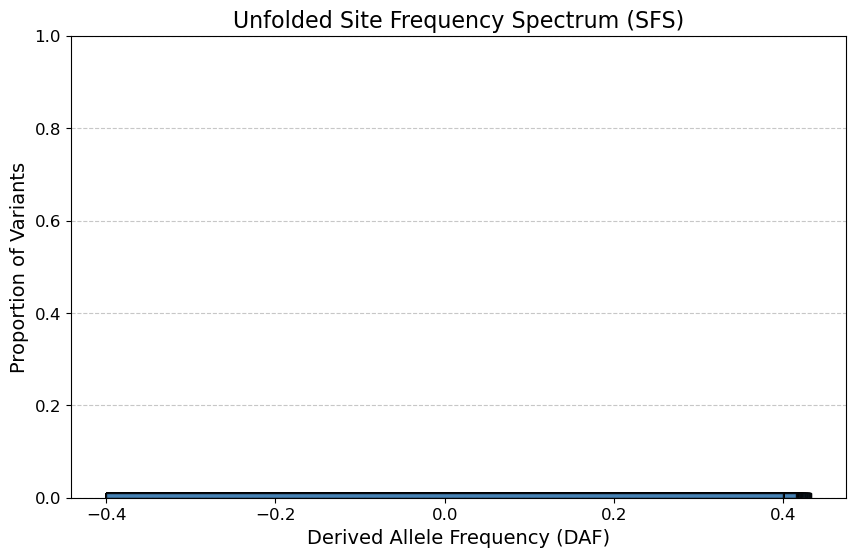

In [54]:


# Plotting the SFS
plt.figure(figsize=(10, 6))
plt.bar(props, daf[:1],color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel("Derived Allele Frequency (DAF)", fontsize=14)
plt.ylabel("Proportion of Variants", fontsize=14)
plt.title("Unfolded Site Frequency Spectrum (SFS)", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


In [141]:
# Set parameters
Ne = 1000000  # Effective population size
sample_size = 89  # Number of samples
recom = 1e-7  # Recombination rate per base pair
mu = 1e-08 # Mutation rate per base pair
num_replicates = 1  # Number of replicates
sequence_length = 1000000  # Length of the chromosome
i = 2  # Replicate index
indx = 0  # Chromosome index (can be expanded for multiple chromosomes)
alpha=1.2

# Define demography for Kingman coalescent
demography_beta = msprime.Demography()
demography_beta.add_population(initial_size=Ne,name="Pop")
demography_beta.add_instantaneous_bottleneck(time=40000, strength=200, population="Pop")

# Simulate ancestry with Kingman coalescent model
ts_beta = msprime.sim_ancestry(
                samples=sample_size,
                sequence_length=sequence_length,
                ploidy=1,
                demography=demography_beta,
               # recombination_rate=recom,
                model=msprime.BetaCoalescent(alpha=alpha)
                )  # Add a random seed for reproducibility

print(f"Replicate {i+1}/{num_replicates}: Ancestry simulated for chromosome {indx+1} with length {sequence_length}")

# Simulate mutations on the ancestry
ts_beta_mut = msprime.sim_mutations(
                ts_beta,
                rate=mu,
                random_seed=42)  # Add a random seed for reproducibility

print(f"Replicate {i+1}/{num_replicates}: Mutations simulated for chromosome {indx+1}")

# Get the number of segregating sites (mutations in the sample)
num_segregating_sites = ts_beta_mut.num_sites
print("Number of segregating sites:", num_segregating_sites)


Replicate 3/1: Ancestry simulated for chromosome 1 with length 1000000
Replicate 3/1: Mutations simulated for chromosome 1
Number of segregating sites: 19


In [143]:
# Set parameters
Ne = 10000# Effective population size
sample_size = 89  # Number of samples
recom = 1e-07  # Recombination rate per base pair
mu = 1e-05  # Mutation rate per base pair
num_replicates = 1  # Number of replicates
sequence_length = 800000  # Length of the chromosome
i = 2  # Replicate index
indx = 0  # Chromosome index (can be expanded for multiple chromosomes)
growth_rate=1000
seed=1236

# Define the population demography with exponential growth
# Define the population demography
demography = msprime.Demography()

# Step 1: Exponential growth forwards in time (infinity to 1000 generations ago)
demography.add_population(initial_size=Ne, growth_rate=growth_rate)  # Start small, grow forwards in time

# Step 2: Constant population size from 1000 generations ago to now
#demography.add_population_parameters_change(time=1000, growth_rate=growth_rate, initial_size=Ne)

# Print the demography debug information
print(demography.debug())


print(f"Simulating chromosome {indx + 1} with length 1000000 bp...")

    # Simulate ancestry with recombination
ts = msprime.sim_ancestry(
        samples=sample_size, 
        recombination_rate=recom, 
        sequence_length=sequence_length,
        demography=demography,
        ploidy=1 
        #random_seed=seed + indx
    )
print(f"Ancestry simulated for chromosome {indx + 1} with length 1000000 bp and recombination rate {recom}")

# Simulate mutations on the ancestry
tree_sequence = msprime.sim_mutations(
        ts,
        rate=mu
      #  random_seed=seed + indx
    )
print(f"Mutations simulated for chromosome {indx + 1}")

# Report the number of segregating sites
num_segregating_sites = tree_sequence.num_sites
print(f"Chromosome {indx + 1}: Number of segregating sites = {num_segregating_sites}")



DemographyDebugger
╠════════════════════════════════╗
║ Epoch[0]: [0, inf) generations ║
╠════════════════════════════════╝
╟    Populations (total=1 active=1)
║    ┌───────────────────────────────────────┐
║    │       │     start│   end│growth_rate  │
║    ├───────────────────────────────────────┤
║    │  pop_0│   10000.0│   0.0│ 1e+03       │
║    └───────────────────────────────────────┘

Simulating chromosome 1 with length 1000000 bp...
Ancestry simulated for chromosome 1 with length 1000000 bp and recombination rate 1e-07
Mutations simulated for chromosome 1
Chromosome 1: Number of segregating sites = 8


In [144]:
def calculate_unfolded_normalized_sfs(tree_sequence, sample_size):
    # Calculate the unfolded SFS
    afs = tree_sequence.allele_frequency_spectrum(polarised=True, span_normalise=False)
    
    # Normalize the SFS (to make it a probability distribution)
    total_alleles = np.sum(afs)
    normalized_sfs = afs / total_alleles
    
    return normalized_sfs


props=calculate_unfolded_normalized_sfs(tree_sequence, 89)
props

array([0.   , 0.875, 0.   , 0.   , 0.   , 0.   , 0.125, 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])

In [82]:
# Set parameters
Ne = 1000000# Effective population size
sample_size = 89  # Number of samples
recom = 1e-7  # Recombination rate per base pair
mu = 1e-08 # Mutation rate per base pair
num_replicates = 1  # Number of replicates
sequence_length = 1000000  # Length of the chromosome
i = 2  # Replicate index
indx = 0  # Chromosome index (can be expanded for multiple chromosomes)
growth_rate=0.001

alpha= 1.1
# Define the population demography with exponential growth
demography = msprime.Demography()

        # Add a single population with the initial size
demography.add_population(name="Pop", initial_size=Ne,growth_rate=1000)

        # Add an instantaneous bottleneck to the single population
demography.add_instantaneous_bottleneck(time=281250, strength=200, population="Pop")

# Print the demography debug information
print(demography.debug())


print(f"Simulating chromosome {indx + 1} with length 1000000 bp...")

    # Simulate ancestry with recombination
ts = msprime.sim_ancestry(
        samples=sample_size, 
        recombination_rate=recom, 
        sequence_length=1000000,
        demography=demography,
        ploidy=1, 
        model=msprime.BetaCoalescent(alpha=alpha)
    )
print(f"Ancestry simulated for chromosome {indx + 1} with length 1000000 bp and recombination rate {recom}")

# Simulate mutations on the ancestry
tree_sequence = msprime.sim_mutations(
        ts,
        rate=mu
    )
print(f"Mutations simulated for chromosome {indx + 1}")

# Report the number of segregating sites
num_segregating_sites = tree_sequence.num_sites
print(f"Chromosome {indx + 1}: Number of segregating sites = {num_segregating_sites}")


DemographyDebugger
╠═════════════════════════════════════╗
║ Epoch[0]: [0, 2.81e+05) generations ║
╠═════════════════════════════════════╝
╟    Populations (total=1 active=1)
║    ┌───────────────────────────────────────┐
║    │     │       start│   end│growth_rate  │
║    ├───────────────────────────────────────┤
║    │  Pop│   1000000.0│   0.0│ 1e+03       │
║    └───────────────────────────────────────┘
╟    Events @ generation 2.81e+05
║    ┌────────────────────────────────────────────────────────────────────────────────────┐
║    │       time│type           │parameters       │effect                                │
║    ├────────────────────────────────────────────────────────────────────────────────────┤
║    │  2.812e+05│Instantaneous  │population=Pop,  │Equivalent to 200 generations of the  │
║    │           │Bottleneck     │strength=200     │coalescent                            │
║    └────────────────────────────────────────────────────────────────────────────────────┘
╠═══

In [33]:
# Draw the genealogical tree as an SVG
svg_tree = tree_sequence.draw_svg()

from IPython.display import SVG


display(SVG(svg_tree))

In [144]:
beta_1_7=ts.load("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/input_vcfs_ts_mhsf/beta_8haps_10Mb/beta_bottleneck/m1e-8/alpha1.7/Beta_bottleneck_rep0_m1e-08_ratio10.0_rs1525225.ts")

In [88]:
def calculate_unfolded_normalized_sfs(tree_sequence, sample_size):
    # Calculate the unfolded SFS
    afs = tree_sequence.allele_frequency_spectrum(polarised=True, span_normalise=False)
    
    # Normalize the SFS (to make it a probability distribution)
    total_alleles = np.sum(afs)
    normalized_sfs = afs / total_alleles
    
    return normalized_sfs


props=calculate_unfolded_normalized_sfs(tree_sequence, 89)
props

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.])

In [5]:
# Assuming `props` is a numpy array
def write_sfs_to_txt(props, filename):
    # Save the normalized SFS to a text file
    np.savetxt(filename, props, fmt='%.8f', delimiter=',', header='Normalized SFS', comments='')

# Call the function to write to a file
write_sfs_to_txt(props, 'normalized_sfs.txt')

In [23]:
# Derived Allele Frequencies (DAF) for plotting
daf = [i / tree_sequence.num_samples for i in range(1, len(props))]


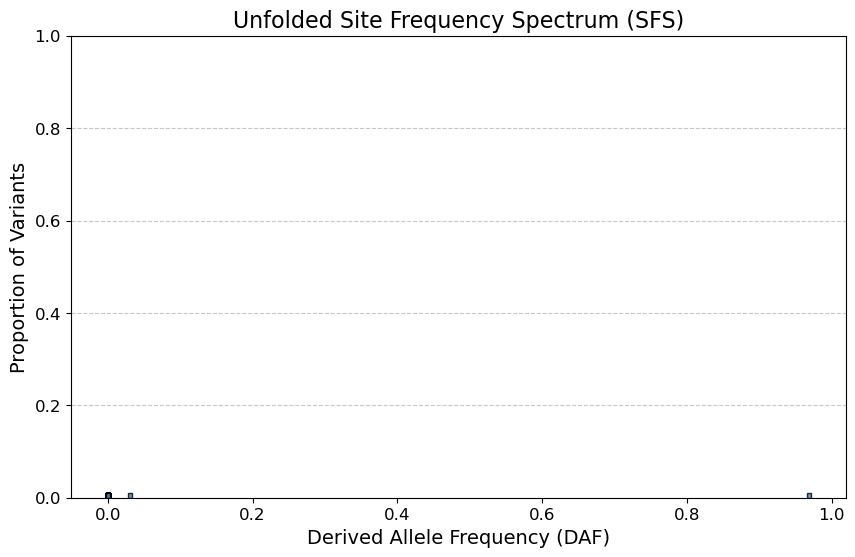

In [33]:
# Plotting the SFS
plt.figure(figsize=(10, 6))
plt.bar(props, daf[:1], color='steelblue', edgecolor='black', alpha=0.8, width=0.005)  # Adjust 'width' to make bars thinner
plt.xlabel("Derived Allele Frequency (DAF)", fontsize=14)
plt.ylabel("Proportion of Variants", fontsize=14)
plt.title("Unfolded Site Frequency Spectrum (SFS)", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()



replicate for paper

In [3]:

import msprime
import os

# Parameters
sample_size = 10
mu = 1e-9  # Mutation rate
r = 1e-8   # Recombination rate
L = 10**7  # Sequence length
Ne = 10**6  # Effective population size

# Set up the demography for msprime simulation
demography = msprime.Demography()
demography.add_population(initial_size=Ne)
demography.add_population_parameters_change(time=100, growth_rate=0, initial_size=Ne / 10)
demography.add_population_parameters_change(time=1000, growth_rate=0, initial_size=Ne)

# Define the directory for saving the files (this path must exist or be created)
output_dir = '/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/input_vcfs_ts_mhsf/new_infiles_trial/paper_redone'
# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Simulation loop for different replicate values (x)
for x in range(1, 11):
    # Use rs as a random seed for reproducibility in each replicate
    rs = ((x + 3) ** 2)
    
    # Simulate the ancestry with recombination rate 'r' and random seed 'rs'
    ts = msprime.sim_ancestry(
        samples=sample_size,
        random_seed=rs,
        recombination_rate=r,
        sequence_length=L,
        demography=demography,
        ploidy=1,
        model=[msprime.StandardCoalescent()]
    )
    
    # Simulate mutations with the mutation rate 'mu'
    mts = msprime.sim_mutations(ts, rate=mu)
    
    # Calculate the ratio (r / mu)
    ratio = float(r / mu)
    
    print(f"Simulation {x}: Ratio of recombination rate to mutation rate: {ratio}")
    
    # Define filenames for the VCF and TreeSequence files
    vcf_filename = os.path.join(
        output_dir, f'Kingman_bottleneck_rep1_m{mu}_ratio{ratio}_rs{rs}.vcf'
    )
    ts_filename = os.path.join(
        output_dir, f'Kingman_bottleneck_rep1_m{mu}_ratio{ratio}_rs{rs}.ts'
    )
    
    # Write the VCF file
    with open(vcf_filename, 'w') as vcffh:
        ts.write_vcf(vcffh, position_transform='legacy', individual_names=[f'spl{str(s)}' for s in range(sample_size)])
    
    # Dump the TreeSequence to a file
    #ts.dump(ts_filename)


KeyboardInterrupt: 